<a href="https://colab.research.google.com/github/abhilasha7744-debug/Student-Marks-Prediction/blob/main/Student_Marks_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [9]:
url = "https://raw.githubusercontent.com/AdiPersonalWorks/Random/master/student_scores%20-%20student_scores.csv"

df = pd.read_csv(url)

df.head()

,Hours,Scores
0,2.5,21
1,5.1,47
2,3.2,27
3,8.5,75
4,3.5,30


In [10]:
print("Shape of Dataset:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

Shape of Dataset: (25, 2)

Columns:
Index(['Hours', 'Scores'], dtype='object')

Data Types:
Hours     float64
Scores      int64
dtype: object


In [11]:
print("Missing Values")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

Missing Values
Hours     0
Scores    0
dtype: int64

Duplicate Rows: 0


In [12]:
df.describe()

,Hours,Scores
count,25.000000,25.000000
mean,5.012000,51.480000
std,2.525094,25.286887
min,1.100000,17.000000
25%,2.700000,30.000000
50%,4.800000,47.000000
75%,7.400000,75.000000
max,9.200000,95.000000


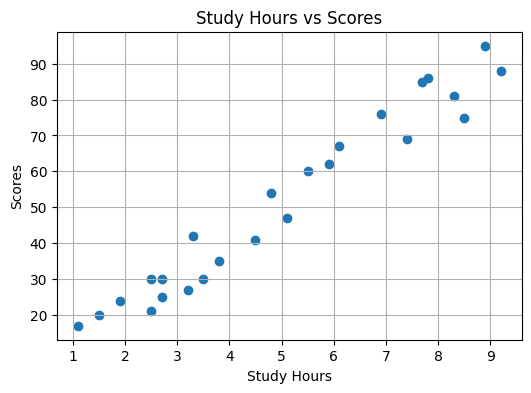

In [13]:
plt.figure(figsize=(6,4))

plt.scatter(df['Hours'], df['Scores'])

plt.title("Study Hours vs Scores")
plt.xlabel("Study Hours")
plt.ylabel("Scores")

plt.grid(True)

plt.show()

In [14]:
X = df[['Hours']]
y = df['Scores']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [15]:
model = LinearRegression()

model.fit(X_train, y_train)

print("Model Trained Successfully")

Model Trained Successfully


In [16]:
y_pred = model.predict(X_test)

result = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

result

,Actual,Predicted
0,81,83.188141
1,30,27.032088
2,21,27.032088
3,76,69.633232
4,62,59.951153


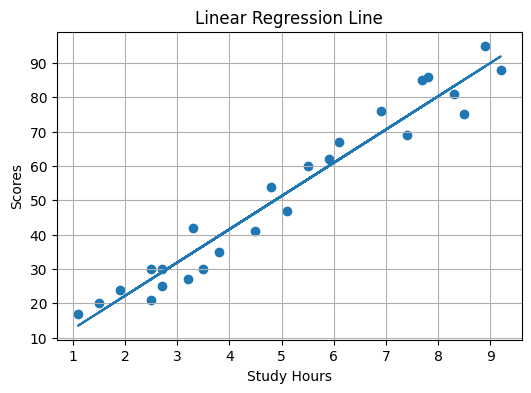

In [17]:
plt.figure(figsize=(6,4))

plt.scatter(df['Hours'], df['Scores'])

plt.plot(df['Hours'], model.predict(df[['Hours']]))

plt.title("Linear Regression Line")
plt.xlabel("Study Hours")
plt.ylabel("Scores")

plt.grid(True)

plt.show()

In [18]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R2 Score:", r2)

Mean Absolute Error (MAE): 3.9207511902099244
Mean Squared Error (MSE): 18.943211722315272
Root Mean Squared Error (RMSE): 4.352380006653288
R2 Score: 0.9678055545167994


In [19]:
study_hours = [[9]]

predicted_marks = model.predict(study_hours)

print("Predicted Marks:", predicted_marks[0])

Predicted Marks: 89.965595744001


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
